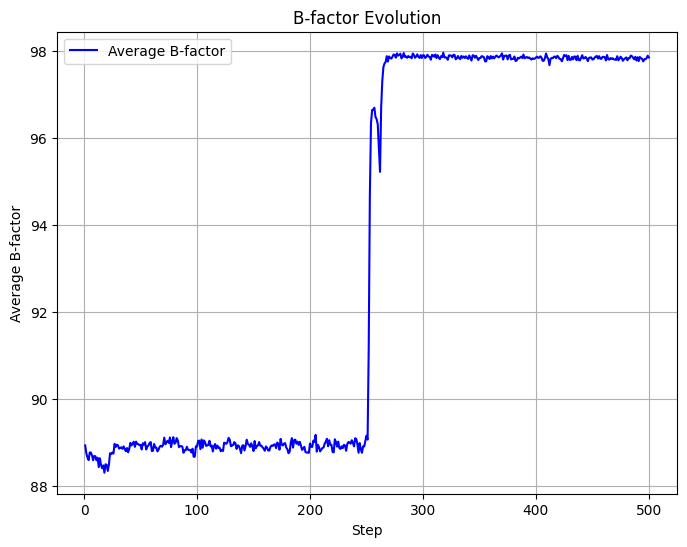

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_b_factors(pdb_file):
    """ 读取 PDB 文件并提取 B-factor（第 11 列）数据的平均值 """
    b_factors = []
    with open(pdb_file, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                fields = line.split()
                try:
                    b_factors.append(float(fields[10]))  # B-factor 在 PDB 文件的第 11 列
                except ValueError:
                    continue  # 忽略无法转换的行
    return np.mean(b_factors) if b_factors else None

# 获取当前目录下的所有 PDB 文件
pdb_files = [f for f in os.listdir('.') if re.match(r'step_(\d+)_.*\.pdb$', f)]

# 按照 step 后的数字排序
pdb_files.sort(key=lambda x: int(re.search(r'step_(\d+)_', x).group(1)))

# 计算 B-factor 平均值
steps = []
b_factors = []

for pdb in pdb_files:
    step = int(re.search(r'step_(\d+)_', pdb).group(1))
    avg_b_factor = extract_b_factors(pdb)
    if avg_b_factor is not None:
        steps.append(step)
        b_factors.append(avg_b_factor)

# 绘制曲线
plt.figure(figsize=(8, 6))
plt.plot(steps, b_factors, linestyle='-', color='b', label='Average B-factor')
plt.xlabel('Step')
plt.ylabel('Average B-factor')
plt.title('B-factor Evolution')
plt.legend()
plt.grid(True)
plt.show()
